In [1]:
# python
import sys
import os
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema, BaseSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
# sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, cutflow
from sidm.tools import llpnanoaodschema
from sidm.tools.llpnanoaodschema import LLPNanoAODSchema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
from tqdm.notebook import tqdm
import coffea.util
import numpy as np
import awkward as ak

In [2]:
client = scaleout.make_dask_client("tls://localhost:8786")
# client.restart()
client

<Client: 'tls://192.168.161.180:8786' processes=1 threads=1, memory=2.89 GiB>

In [3]:
do_Dask = True

In [4]:
samples = ["2Mu2E_200GeV_5p0GeV_20p0mm"]
fileset = utilities.make_fileset(samples[0:1], 
                                 "llpNanoAOD_v2", 
                                 location_cfg="signal_2mu2e_v10.yaml",
                                 max_files = 1,
                                )
fileset

{'2Mu2E_200GeV_5p0GeV_20p0mm': {'files': ['root://xcache//store/group/lpcmetx/SIDM/ULSignalSamples/2018_v10/BsTo2DpTo2Mu2e/CutDecayFalse_SIDM_BsTo2DpTo2Mu2e_MBs-200_MDp-5p0_ctau-20p0_v3/LLPnanoAODv2/CutDecayFalse_SIDM_BsTo2DpTo2Mu2e_MBs-200_MDp-5p0_ctau-20p0_v3_part-0.root'],
  'metadata': {'skim_factor': 1.0, 'is_data': False, 'year': '2018'}}}

In [5]:
channels = ["base"]  # "baseNoLjNoLjsource", "baseNoLj", "base_ljObjCut", "base",
print(f"Running on sample: {samples[0]}")

Running on sample: 2Mu2E_200GeV_5p0GeV_20p0mm


In [6]:
p_skim = sidm_processor.SidmProcessor(
    channel_names=channels,
    hist_collection_names=["lj_base"],
    lj_reco_choices=["0.4"],
    skim_mode=True,
    verbose=True
)

if (not do_Dask):
    print("Starting Local Skim Run...")
    runner = processor.Runner(
        executor=processor.IterativeExecutor(),
        schema=llpnanoaodschema.LLPNanoAODSchema,
        skipbadfiles=True
    )
elif (do_Dask):
    print("Starting Dask Skim Run...")
    runner = processor.Runner(
        executor=processor.DaskExecutor(client=client, compression=None),
        schema=llpnanoaodschema.LLPNanoAODSchema,
        skipbadfiles=True
    )

# Run the processor
output = runner(fileset, treename="Events", processor_instance=p_skim)
dataset_key = list(output.keys())[0]
results = output[dataset_key]
results_original = results

print(output)

Starting Dask Skim Run...


Output()

Output()

Signal not in xs cfg, assuming 1fb
{'2Mu2E_200GeV_5p0GeV_20p0mm': {'cutflow': {'base': <sidm.tools.cutflow.Cutflow object at 0x7f53bac56570>}, 'hists': {'lj_n': <sidm.tools.histogram.Histogram object at 0x7f53bac54e30>, 'lj_pt': <sidm.tools.histogram.Histogram object at 0x7f53bac59c70>, 'lj_eta_phi': <sidm.tools.histogram.Histogram object at 0x7f53badc83e0>, 'lj0_pt': <sidm.tools.histogram.Histogram object at 0x7f53bae07c20>, 'lj1_pt': <sidm.tools.histogram.Histogram object at 0x7f53bae07620>, 'lj0_e': <sidm.tools.histogram.Histogram object at 0x7f53bae07320>, 'lj1_e': <sidm.tools.histogram.Histogram object at 0x7f53bae05e20>, 'lj0_dRSpread': <sidm.tools.histogram.Histogram object at 0x7f53bae05cd0>, 'lj1_dRSpread': <sidm.tools.histogram.Histogram object at 0x7f53bae06030>, 'lj_electronN': <sidm.tools.histogram.Histogram object at 0x7f53bae05a60>, 'lj_photonN': <sidm.tools.histogram.Histogram object at 0x7f53bae07710>, 'lj_electronPhotonN': <sidm.tools.histogram.Histogram object at 0x7

In [7]:
print(results_original.keys())
print(results_original['cutflow']['base'].print_table())
print()

print(results_original.keys())
print(results_original['cutflow']['base'].print_table(unweighted=True))
print()


for key in results_original["counters"]['0.4']['base'].keys():
    print(key, results_original["counters"]['0.4']['base'][key].value)
print()

print(results_original['hists'].keys())
import mplhep as hep
hist_list = []
hist_obj = results_original['hists']["lj_pt"]
hist_data = hist_obj.hist
hist_1d = hist_data[channels[0], :] 
hist_list.append(hist_1d)

# plt.subplots(1,1,figsize=(6,6))
# plt.subplot(1,1,1)
# hep.histplot(hist_list) 
# plt.legend(["base (Yes CC) Pre"])
# plt.show()

dict_keys(['cutflow', 'hists', 'counters', 'skims', 'metadata'])
cut name         individual cut N    all cut N
-------------  ------------------  -----------
No selection                 59.8         59.8
pass triggers                17.4         17.4
PV filter                    59.8         17.4
>=2 LJs                      33.8         11.8
None

dict_keys(['cutflow', 'hists', 'counters', 'skims', 'metadata'])
cut name         individual cut N    all cut N
-------------  ------------------  -----------
No selection               1609.0       1609.0
pass triggers               469.0        469.0
PV filter                  1609.0        469.0
>=2 LJs                     908.0        316.0
None

Total LJs 633
Gen As to muons 316
Gen As to electrons 316
Matched gen As to muons 315
Matched gen As to electrons 316

dict_keys(['lj_n', 'lj_pt', 'lj_eta_phi', 'lj0_pt', 'lj1_pt', 'lj0_e', 'lj1_e', 'lj0_dRSpread', 'lj1_dRSpread', 'lj_electronN', 'lj_photonN', 'lj_electronPhotonN', 'lj_muonN',

In [8]:
results_original["metadata"]

{'n_evts': value_accumulator(int, 1609),
 'scaled_sum_weights': value_accumulator(float, np.float32(1609.0))}

In [9]:
skim_chunks = results_original["skims"]["0.4"][channels[0]]
print(skim_chunks)
print(f"\nSkim finished. Collected {len(skim_chunks)} chunks.")

if len(skim_chunks) > 0:
    skim_data = ak.concatenate(skim_chunks)
    print(f"Total events: {len(skim_data)}")

    cutflow_obj = results_original['cutflow']['base']
    original_sum_weights = cutflow_obj.cut_breakdown()[0]
    skimmed_sum_weights = cutflow_obj.cut_breakdown()[-1]

    my_skim_factor = skimmed_sum_weights / original_sum_weights
    print(my_skim_factor)

    print(f"Original Sum: {original_sum_weights}")
    print(f"Skimmed Sum:  {skimmed_sum_weights}")
    print(f"Skim Factor:  {my_skim_factor}")

    filename = "compatible_skim_test.parquet"
    print(f"Saving to {filename}...")
    
    ak.to_parquet(skim_data, filename)
    print("Success! File saved.")
    
else:
    print("Warning: No events selected!")

[<Array [{run: 1, nGenJetAK8: 2, ...}, ...] type='316 * {run: uint32, nGenJe...'>]

Skim finished. Collected 1 chunks.
Total events: 316
0.19639528
Original Sum: 59.83000183105469
Skimmed Sum:  11.750329971313477
Skim Factor:  0.19639527797698975
Saving to compatible_skim_test.parquet...
Success! File saved.


In [11]:
print("Reloading from Parquet...")
reloaded_events = NanoEventsFactory.from_parquet(
    filename, 
    schemaclass=llpnanoaodschema.LLPNanoAODSchema,
    metadata={"dataset": samples[0],
              "skim_factor": my_skim_factor,
             }
).events()

print("\n--- Integrity Check ---")
print(f"GenParticles: {len(reloaded_events.GenPart)}")
print(f"Has Flags?    {reloaded_events.GenPart.hasFlags('isPrompt')[:3]}")
print(f"Children?     {reloaded_events.GenPart.children[:3]}")

try:
    # Check if the cross-reference works now
    if "dsaMuons" in reloaded_events.fields:
        coll = reloaded_events.dsaMuons
    else:
        coll = reloaded_events.DSAMuon
        
    print(f"DSAMuon collection found: {coll}")
    # print(coll.fields)
    
    # Try accessing the cross-reference
    if hasattr(coll, "matched_muons"):
        print(f"✅ matched_muons exists! Example: {coll.matched_muons[0]}")
    else:
        print("❌ matched_muons still missing from the object.")
        
except Exception as e:
    print(f"⚠️ Error checking DSAMuons: {e}")
    
try:
    if "BS" in reloaded_events.fields:
        coll = reloaded_events.BS
        
    print(f"Beam Spot collection 'BS' found: {coll}")
    if hasattr(coll, "x"):
        print(f"✅ x exists! Example: {coll.x[0]}")
    else:
        print("❌ x still missing from the object.")
except Exception as e:
    print(f"⚠️ Error checking Beam Spot: {e}")

Reloading from Parquet...


/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(



--- Integrity Check ---
GenParticles: 316
Has Flags?    [[True, True, True, True, True, ..., False, False, False, False, False], ...]
Children?     [[[{eta: ??, mass: ??, phi: ??, pt: ??, genPartIdxMother: ??, ...}], ...], ...]
DSAMuon collection found: [??, ??, ??, ??, ??, ??, ??, ??, ??, ..., ??, ??, ??, ??, ??, ??, ??, ??, ??]
✅ matched_muons exists! Example: [[LLPMuon, ...], ...]
Beam Spot collection 'BS' found: [??, ??, ??, ??, ??, ??, ??, ??, ??, ..., ??, ??, ??, ??, ??, ??, ??, ??, ??]
✅ x exists! Example: [??]


In [12]:
# Full Analysis (Scalable Way)
from sidm.tools import utilities

# Define Inputs (Mimics standard fileset)
skim_fileset = {
    samples[0]: { 
        "files": ["compatible_skim_test.parquet"] 
        # In the future, this list will have ["part0.parquet", "part1.parquet", ...]
    }
}
channels_new = ['baseNoLj']

# Define Metadata (The skim factor we calculated)
skim_meta = {
             "dataset": samples[0],
             "skim_factor": my_skim_factor
            }

# Instantiate Processor
p_analysis = sidm_processor.SidmProcessor(
    channel_names=channels_new,
    hist_collection_names=["lj_base"],
    skim_mode=False
)

print("\n--- Running Parquet Analysis (via Utility) ---")

# Run
# Pass 'executor=client' here to run on Dask workers?
output = utilities.run_parquet_analysis(
    skim_fileset, 
    p_analysis, 
    metadata=skim_meta,
    # executor=client
)

# Validation
dataset_key = samples[0]
results = output[dataset_key]


--- Running Parquet Analysis (via Utility) ---
Submitting 1 tasks to Local...


/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------
Accumulating results...
Post-processing...
Signal not in xs cfg, assum

dict_keys(['cutflow', 'hists', 'counters', 'skims', 'metadata'])
cut name         individual cut N    all cut N
-------------  ------------------  -----------
No selection                 11.8         11.8
pass triggers                11.8         11.8
PV filter                    11.8         11.8
None

dict_keys(['cutflow', 'hists', 'counters', 'skims', 'metadata'])
cut name         individual cut N    all cut N
-------------  ------------------  -----------
No selection                316.0        316.0
pass triggers               316.0        316.0
PV filter                   316.0        316.0
None

Histograms generated: 15
dict_keys(['lj_n', 'lj_pt', 'lj_eta_phi', 'lj0_pt', 'lj1_pt', 'lj0_e', 'lj1_e', 'lj0_dRSpread', 'lj1_dRSpread', 'lj_electronN', 'lj_photonN', 'lj_electronPhotonN', 'lj_muonN', 'lj_dsaMuN', 'lj_pfMuN'])


/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


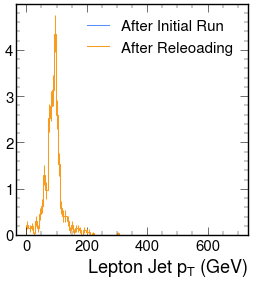

In [13]:
print(results.keys())
print(results['cutflow'][channels_new[0]].print_table())
print()

print(results.keys())
print(results['cutflow'][channels_new[0]].print_table(unweighted=True))
print()

print(f"Histograms generated: {len(results['hists'])}")
print(results['hists'].keys())

import mplhep as hep
hist_obj = results['hists']["lj_pt"]
hist_data = hist_obj.hist
hist_1d = hist_data[channels_new[0], :] 
hist_list.append(hist_1d)

plt.subplots(1,1,figsize=(6,6))
plt.subplot(1,1,1)
hep.histplot(hist_list) 
plt.legend(["After Initial Run", "After Releoading"])
plt.show()

In [14]:
# Compare Original vs Reloaded Counts
orig_count = results_original["cutflow"][channels[0]].cut_breakdown()[-1]
reload_count = results["cutflow"][channels_new[0]].cut_breakdown()[-1]

print(f"Original Yield: {orig_count}")
print(f"Reloaded Yield: {reload_count}")

if abs(orig_count - reload_count) < 1e-5:
    print("SUCCESS: Yields are identical!")
else:
    print("WARNING: Yields differ!")

Original Yield: 11.750329971313477
Reloaded Yield: 11.750329971313477
SUCCESS: Yields are identical!
